<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #0284c7; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Reducción de Dimensionalidad con PCA 🌌📉
      </h1>
      <p style="margin: 6px 0 0 0; color: #0284c7; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Principal Component Analysis
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #0369a1; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 01 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #0284c7; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/04_Reduccion_de_Dimensionalidad_con_PCA.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Motivación: la maldición de la dimensionalidad y la redundancia de variables 🌌

Los Cuadernos 00 a 03 de este módulo dejaron el dataset `dataset_crudo_preprocesamiento.csv` completamente numérico, sin nulos y en una escala común. El resultado es una matriz con **11 columnas** (5 numéricas originales + 1 columna ordinal + 5 columnas binarias de One-Hot Encoding) — y ese número solo puede crecer en datasets reales, donde decenas o cientos de variables terminan describiendo, muchas veces, el mismo fenómeno subyacente desde ángulos distintos.

Esto trae dos problemas prácticos, conocidos conjuntamente como la **maldición de la dimensionalidad**:

* **Redundancia:** en el Cuaderno 00 (Sección 4) ya se documentó que `ingreso_mensual` y `monto_prestamo` tienen una correlación de **r = 0.971** — casi toda la información de una está contenida en la otra. Mantener ambas como columnas independientes no añade información proporcional al costo computacional y de interpretación que suman.
* **Dispersión geométrica:** a medida que se agregan columnas, el volumen del espacio crece exponencialmente y los datos —por muchos que sean— quedan cada vez más dispersos dentro de ese espacio. Las nociones de "distancia" o "vecindad" que usan KNN, K-Means o SVM se vuelven menos informativas cuantas más dimensiones (especialmente si son redundantes o ruidosas) hay que atravesar.

**PCA (Análisis de Componentes Principales)** ataca ambos problemas a la vez: en lugar de descartar columnas a mano, construye un nuevo conjunto de ejes —**combinaciones lineales de las columnas originales**— ordenados de mayor a menor varianza capturada, y **no correlacionados entre sí**. Quedarse solo con los primeros de esos ejes permite comprimir la información redundante en menos dimensiones, reteniendo la mayor parte posible de la variabilidad real de los datos.

In [218]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "dataset_crudo_preprocesamiento.csv": "..."
}

def load_dataset(filename="dataset_crudo_preprocesamiento.csv", module_name="01 - Preprocesamiento de los Datos"):
    """
    Carga o descarga de forma segura el dataset para ejecución local o en Google Colab.
    Si no se encuentra localmente ni en GitHub, lo restaura automáticamente de forma exacta.
    """
    candidates = [
        os.path.join("data", filename),
        os.path.join(module_name, "data", filename),
        os.path.join("..", "data", filename),
        os.path.join("..", module_name, "data", filename),
        os.path.join("..", "..", "data", filename),
        os.path.join("Data Mining", module_name, "data", filename),
        os.path.join("..", "Data Mining", module_name, "data", filename),
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path

    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    folder_path = f"Data Mining/{module_name}"
    encoded_folder = urllib.parse.quote(folder_path)
    encoded_file = urllib.parse.quote(filename)

    urls = [
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_folder}/data/{encoded_file}",
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_folder}/data/{encoded_file}"
    ]

    print(f"[INFO] Intentando descargar '{filename}' desde el repositorio oficial...")
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=2) as response:
                if response.status == 200:
                    with open(target_path, "wb") as out_f:
                        out_f.write(response.read())
                    print(f"[OK] Dataset '{filename}' descargado exitosamente.")
                    return target_path
        except Exception:
            continue

    if filename in _DATA_EMBEDDED:
        print(f"[INFO] Restaurando '{filename}' de forma autonoma...")
        data_bytes = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target_path, "wb") as out_f:
            out_f.write(data_bytes)
        print(f"[OK] Dataset '{filename}' preparado exitosamente en '{target_path}'.")
        return target_path

    raise FileNotFoundError(f"No se pudo encontrar ni generar el dataset '{filename}'.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv(load_dataset("dataset_crudo_preprocesamiento.csv"))

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

Dimensiones del dataset: 2000 filas x 8 columnas


,id_cliente,edad,ingreso_mensual,escolaridad,canal_contacto,score_credito,tasa_interes,monto_prestamo
0,CLI-000001,44.00,"21,901,987.81",Primaria,Web,632.50,1.23,"77,701,191.55"
1,CLI-000002,36.00,"4,774,766.59",Pregrado,APP,766.00,2.66,"15,463,467.25"
2,CLI-000003,46.00,"323,240.15",Secundaria,NaN,601.30,2.42,"1,439,715.06"
3,CLI-000004,56.00,"20,740,217.29",Secundaria,Web,600.90,3.41,"81,635,521.51"
4,CLI-000005,35.00,"2,201,094.03",Secundaria,Call Center,662.60,4.30,"12,592,460.72"


---
## 2. Recapitulación exprés: el pipeline completo de los Cuadernos 00-03 🔧

PCA solo tiene sentido sobre una matriz **numérica, sin nulos y en una escala común** — es literalmente una técnica que maximiza varianza, así que cualquier columna sin escalar, cualquier nulo sin tratar o cualquier categoría sin codificar la distorsiona o directamente la rompe. Antes de tocar `sklearn.decomposition.PCA`, se reconstruye aquí —de forma concisa, sin volver a justificar cada decisión— el pipeline completo armado a lo largo del módulo:

| Paso | Técnica | Cuaderno donde se justificó |
|---|---|---|
| Tratar valores imposibles de `edad` (-3, 150 años) | Convertir a `NaN` los valores fuera de `[18, 100]` | Cuaderno 01 (Outliers) |
| Imputar columnas numéricas | `SimpleImputer(strategy="median")` | Cuaderno 00 (Imputación) |
| Imputar y codificar `escolaridad` | Moda + `OrdinalEncoder` con orden explícito | Cuaderno 00 y Cuaderno 03 |
| Limpiar y codificar `canal_contacto` | `.str.strip().title()` + mapeo + `OneHotEncoder` | Cuaderno 03 (Encoding) |
| Escalar la matriz completa | `StandardScaler` | Cuaderno 02 (Escalado) |

**Nota de diseño importante:** las 5 columnas binarias generadas por One-Hot Encoding también se incluyen en el `StandardScaler` final, junto con las columnas numéricas y la ordinal. Esto no es la única convención posible (algunos flujos dejan las dummies sin escalar, ya que ya están acotadas en $[0,1]$), pero para PCA —que compara varianzas entre columnas para decidir qué dirección es "principal"— es la opción más consistente: si las dummies quedaran sin escalar mientras las columnas financieras sí, la escala relativa entre ambos grupos volvería a depender de una elección arbitraria, exactamente el problema que el Cuaderno 02 ya resolvió una vez.

In [219]:
columnas_numericas = ["edad", "ingreso_mensual", "score_credito", "tasa_interes", "monto_prestamo"]

# Outliers de dominio en 'edad' (Cuaderno 01): valores fuera de un rango humano plausible
# se tratan como NaN para que el mismo paso de imputacion por mediana (Cuaderno 00) los resuelva.
df["edad"] = df["edad"].where(df["edad"].between(18, 100), np.nan)
print(f"Nulos en 'edad' tras marcar los valores imposibles (-3, 150, etc.) como NaN: {df['edad'].isnull().sum()}")

imputer_num = SimpleImputer(strategy="median")
df[columnas_numericas] = imputer_num.fit_transform(df[columnas_numericas])
print(f"Nulos en columnas numericas tras imputacion por mediana: {df[columnas_numericas].isnull().sum().sum()}")

Nulos en 'edad' tras marcar los valores imposibles (-3, 150, etc.) como NaN: 168
Nulos en columnas numericas tras imputacion por mediana: 0


In [220]:
imputer_escolaridad = SimpleImputer(strategy="most_frequent")
df["escolaridad"] = imputer_escolaridad.fit_transform(df[["escolaridad"]]).ravel()

orden_escolaridad = ["Primaria", "Secundaria", "Pregrado", "Posgrado"]
encoder_ordinal = OrdinalEncoder(categories=[orden_escolaridad])
df["escolaridad_ordinal"] = encoder_ordinal.fit_transform(df[["escolaridad"]]).ravel()

print("Nulos en 'escolaridad' tras imputacion por moda:", df["escolaridad"].isnull().sum())
print("Mapeo ordinal aplicado:", {c: i for i, c in enumerate(orden_escolaridad)})

Nulos en 'escolaridad' tras imputacion por moda: 0
Mapeo ordinal aplicado: {'Primaria': 0, 'Secundaria': 1, 'Pregrado': 2, 'Posgrado': 3}


In [221]:
canal_limpio = df["canal_contacto"].str.strip().str.title().replace({"App": "App Movil"})
canal_limpio = canal_limpio.fillna("Desconocido")
df["canal_contacto_limpio"] = canal_limpio

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
canal_ohe = ohe.fit_transform(df[["canal_contacto_limpio"]])
df_canal = pd.DataFrame(canal_ohe, columns=list(ohe.get_feature_names_out()), index=df.index)

print("Categorias de 'canal_contacto' tras la limpieza:")
print(df["canal_contacto_limpio"].value_counts())
print(f"\nColumnas generadas por One-Hot Encoding: {df_canal.shape[1]}")

Categorias de 'canal_contacto' tras la limpieza:
canal_contacto_limpio
App Movil      702
Web            684
Sucursal       373
Call Center    201
Desconocido     40
Name: count, dtype: int64

Columnas generadas por One-Hot Encoding: 5


In [222]:
X = pd.concat([df[columnas_numericas + ["escolaridad_ordinal"]], df_canal], axis=1)
print(f"Matriz de caracteristicas ensamblada: {X.shape[0]} filas x {X.shape[1]} columnas")
print("Columnas:", X.columns.tolist())
print(f"Nulos totales en X: {X.isnull().sum().sum()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nMedia por columna tras StandardScaler (debe ser ~0): {np.round(X_scaled.mean(axis=0), 6)}")
print(f"Desviacion estandar por columna tras StandardScaler (debe ser ~1): {np.round(X_scaled.std(axis=0), 6)}")

Matriz de caracteristicas ensamblada: 2000 filas x 11 columnas
Columnas: ['edad', 'ingreso_mensual', 'score_credito', 'tasa_interes', 'monto_prestamo', 'escolaridad_ordinal', 'canal_contacto_limpio_App Movil', 'canal_contacto_limpio_Call Center', 'canal_contacto_limpio_Desconocido', 'canal_contacto_limpio_Sucursal', 'canal_contacto_limpio_Web']
Nulos totales en X: 0

Media por columna tras StandardScaler (debe ser ~0): [ 0. -0.  0. -0.  0.  0. -0. -0. -0.  0. -0.]
Desviacion estandar por columna tras StandardScaler (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 3. Intuición matemática: ¿qué es exactamente un componente principal? 📐

Geométricamente, cada fila de `X_scaled` es un punto en un espacio de 11 dimensiones. PCA busca la dirección (un vector unitario) sobre la cual, al proyectar todos esos puntos, **la varianza de las proyecciones es máxima**. A esa dirección se le llama **primera componente principal (PC1)**. Luego busca la siguiente dirección de mayor varianza posible que sea **ortogonal** (perpendicular, no correlacionada) a la primera — esa es **PC2** — y así sucesivamente, hasta agotar tantas direcciones como columnas originales.

Formalmente, esas direcciones son los **autovectores** de la matriz de covarianza $\Sigma$ de los datos estandarizados, y la varianza que capturan es su **autovalor** correspondiente:

$$\Sigma v_i = \lambda_i v_i$$

donde $v_i$ es la dirección de la $i$-ésima componente principal y $\lambda_i$ es la varianza que esa componente explica. Ordenar los autovalores de mayor a menor da, directamente, el orden de importancia de las componentes. (En la práctica, `scikit-learn` no calcula la matriz de covarianza explícitamente por razones numéricas — usa **descomposición en valores singulares, SVD**, sobre la matriz de datos centrada, que es matemáticamente equivalente pero más estable — pero el resultado final, los mismos autovectores y autovalores, es idéntico.)

La siguiente celda lo verifica de forma concreta: se calcula la matriz de covarianza de `X_scaled` a mano con NumPy, se extraen sus autovalores, y se comparan con lo que reporta `PCA` de scikit-learn.

In [223]:
matriz_covarianza = np.cov(X_scaled, rowvar=False)
autovalores, autovectores = np.linalg.eigh(matriz_covarianza)
orden_desc = np.argsort(autovalores)[::-1]
autovalores_ordenados = autovalores[orden_desc]

print("Autovalores de la matriz de covarianza (orden descendente), primeros 5:")
print(np.round(autovalores_ordenados[:5], 4))

print(f"\nRango de la matriz X_scaled: {np.linalg.matrix_rank(X_scaled)} (de {X_scaled.shape[1]} columnas)")
print("(Una columna 'de sobra': las 5 columnas de One-Hot de canal_contacto siempre suman 1 por fila,")
print(" asi que son linealmente dependientes entre si -- se retoma esta observacion en la Seccion 8.)")

Autovalores de la matriz de covarianza (orden descendente), primeros 5:
[1.9774 1.5367 1.3186 1.1586 1.0652]

Rango de la matriz X_scaled: 10 (de 11 columnas)
(Una columna 'de sobra': las 5 columnas de One-Hot de canal_contacto siempre suman 1 por fila,
 asi que son linealmente dependientes entre si -- se retoma esta observacion en la Seccion 8.)


---
## 4. Ajustando `PCA` con scikit-learn 🧮

`sklearn.decomposition.PCA` implementa exactamente ese cálculo. Al llamar `.fit()` (o `.fit_transform()`) sobre `X_scaled`, el objeto aprende las 11 componentes principales (tantas como columnas de entrada, por defecto) y expone `.explained_variance_ratio_`: la fracción de la varianza total que cada componente, por sí sola, logra explicar.

In [224]:
pca = PCA()
componentes_principales = pca.fit_transform(X_scaled)

print("Autovalores obtenidos por PCA (pca.explained_variance_), primeros 5:")
print(np.round(pca.explained_variance_[:5], 4))
coinciden = np.allclose(autovalores_ordenados, pca.explained_variance_, atol=1e-6)
print(f"¿Coinciden con los autovalores calculados manualmente en la Seccion 3? {coinciden}")

print("\nVarianza explicada por cada componente:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {ratio*100:.2f}%")

Autovalores obtenidos por PCA (pca.explained_variance_), primeros 5:
[1.9774 1.5367 1.3186 1.1586 1.0652]
¿Coinciden con los autovalores calculados manualmente en la Seccion 3? True

Varianza explicada por cada componente:
  PC1: 17.97%
  PC2: 13.96%
  PC3: 11.98%
  PC4: 10.53%
  PC5: 9.68%
  PC6: 9.37%
  PC7: 9.03%
  PC8: 8.71%
  PC9: 8.52%
  PC10: 0.26%
  PC11: 0.00%


---
## 5. Varianza explicada acumulada (scree plot) 📈

Ninguna componente individual explica una fracción abrumadora de la varianza total —lo cual, dado que la matriz de entrada mezcla columnas numéricas y variables dummy poco correlacionadas entre sí, es esperable—. La pregunta más útil no es "¿cuánto explica PC1?" sino "¿**cuántas** componentes hacen falta para retener una fracción aceptable (80%, 90%, 95%) de la varianza total?". Esa es, precisamente, la lectura de un **scree plot** acumulado.

Text(0.5, 0, 'Numero de componentes principales')

Text(0, 0.5, 'Varianza acumulada explicada (%)')

Text(0.5, 1.0, 'Varianza explicada acumulada (scree plot)')

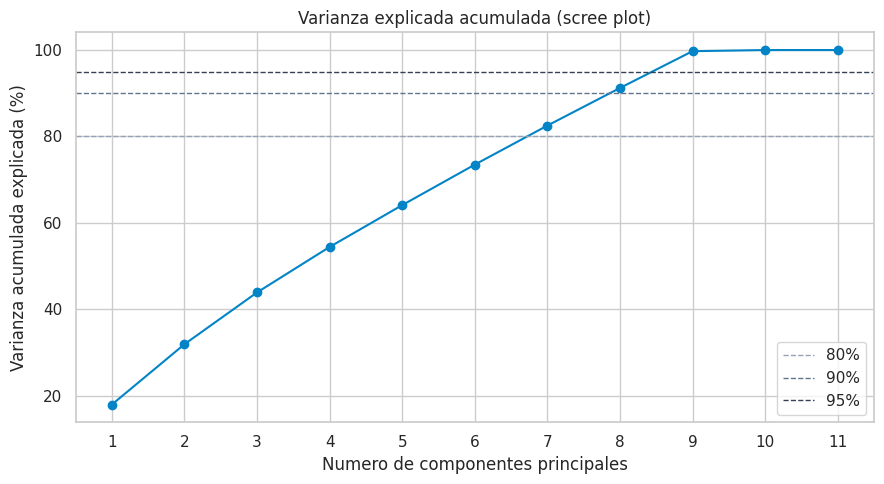

Componentes necesarios para retener >=80% de la varianza: 7
Componentes necesarios para retener >=90% de la varianza: 8
Componentes necesarios para retener >=95% de la varianza: 9
Varianza retenida por los 2 primeros componentes (PC1+PC2), usados en el biplot: 31.93%


In [225]:
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada * 100, marker="o", color="#0284c7")
ax.axhline(80, color="#94a3b8", linestyle="--", linewidth=1, label="80%")
ax.axhline(90, color="#64748b", linestyle="--", linewidth=1, label="90%")
ax.axhline(95, color="#334155", linestyle="--", linewidth=1, label="95%")
ax.set_xlabel("Numero de componentes principales")
ax.set_ylabel("Varianza acumulada explicada (%)")
ax.set_title("Varianza explicada acumulada (scree plot)")
ax.set_xticks(range(1, len(varianza_acumulada) + 1))
ax.legend()
plt.tight_layout()
plt.show()

n_80 = int(np.argmax(varianza_acumulada >= 0.80) + 1)
n_90 = int(np.argmax(varianza_acumulada >= 0.90) + 1)
n_95 = int(np.argmax(varianza_acumulada >= 0.95) + 1)
print(f"Componentes necesarios para retener >=80% de la varianza: {n_80}")
print(f"Componentes necesarios para retener >=90% de la varianza: {n_90}")
print(f"Componentes necesarios para retener >=95% de la varianza: {n_95}")
print(f"Varianza retenida por los 2 primeros componentes (PC1+PC2), usados en el biplot: {pca.explained_variance_ratio_[:2].sum()*100:.2f}%")

Sobre estos 11 columnas concretas hacen falta **7 componentes para retener el 80%**, **8 para el 90%** y **9 para el 95%** de la varianza total — una reducción modesta (de 11 a 7-9), no la compresión dramática que a veces se espera de PCA. La razón es honesta y verificable con lo ya visto en el módulo: solo `ingreso_mensual` y `monto_prestamo` están realmente correlacionadas entre sí (r = 0.971, Cuaderno 00); `score_credito`, `tasa_interes`, `edad` y las columnas dummy de `canal_contacto` son, en su mayoría, casi independientes unas de otras. **PCA solo puede comprimir donde hay redundancia real** — colapsa el par ingreso/préstamo en (esencialmente) una sola dirección, pero no puede inventar correlación donde no la hay entre el resto de columnas. Nótese también que **PC1 + PC2 (las dos usadas en el biplot de la Sección 7) retienen apenas el 31.93% de la varianza total**: el biplot 2D es una vista útil e intuitiva, pero parcial — no sustituye a las 7-9 componentes que hacen falta para una representación fiel.

---
## 6. Interpretando los *loadings*: ¿qué variables dominan cada componente? 🔍

Cada componente principal es una combinación lineal de las columnas originales: $PC_i = \sum_j w_{ij} \cdot x_j$. Esos coeficientes $w_{ij}$ —llamados ***loadings*** o cargas— indican **cuánto pesa cada variable original en cada componente**, y con qué signo. Un *loading* cercano a 0 significa que esa variable casi no contribuye a esa componente; un *loading* con magnitud cercana a 1 (en valor absoluto) significa que la componente está casi determinada por esa única variable. `pca.components_` almacena exactamente esta matriz (una fila por componente, una columna por variable original).

Loadings de PC1, ordenados por magnitud:


,PC1
ingreso_mensual,0.70
monto_prestamo,0.70
canal_contacto_limpio_Web,0.05
canal_contacto_limpio_Call Center,-0.04
edad,-0.04
canal_contacto_limpio_App Movil,-0.02
canal_contacto_limpio_Desconocido,-0.02
canal_contacto_limpio_Sucursal,0.01
tasa_interes,-0.00
escolaridad_ordinal,-0.00



Loadings de PC2, ordenados por magnitud:


,PC2
canal_contacto_limpio_App Movil,0.71
canal_contacto_limpio_Web,-0.70
score_credito,-0.08
tasa_interes,0.07
monto_prestamo,0.04
edad,0.04
ingreso_mensual,0.03
canal_contacto_limpio_Sucursal,-0.02
canal_contacto_limpio_Call Center,-0.01
escolaridad_ordinal,-0.01


<Axes: >

Text(0.5, 1.0, 'Loadings de las primeras 4 componentes principales')

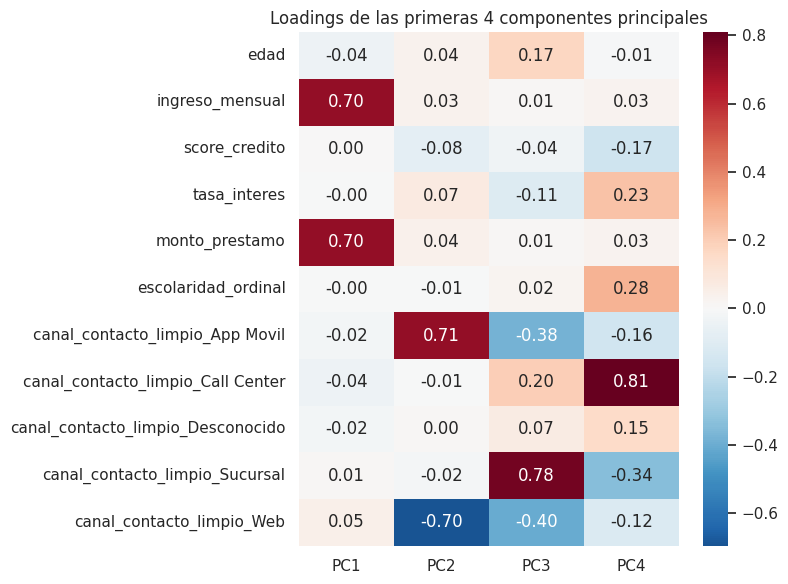

In [226]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)

print("Loadings de PC1, ordenados por magnitud:")
display(loadings["PC1"].sort_values(key=lambda s: s.abs(), ascending=False))
print("\nLoadings de PC2, ordenados por magnitud:")
display(loadings["PC2"].sort_values(key=lambda s: s.abs(), ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings.iloc[:, :4], annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Loadings de las primeras 4 componentes principales")
plt.tight_layout()
plt.show()

**Lectura de los resultados:**

* **PC1** está dominada casi por completo por `ingreso_mensual` (loading ≈ 0.70) y `monto_prestamo` (loading ≈ 0.70), con el resto de columnas por debajo de 0.05 en magnitud. Es exactamente lo esperable: PCA "encontró" solo por su cuenta el par de variables correlacionadas (r = 0.971) que ya se había identificado en el Cuaderno 00, y las fusionó en una única dirección que se puede leer como un eje de **"magnitud financiera de la solicitud"**.
* **PC2** está dominada casi por completo por dos columnas dummy: `canal_contacto_limpio_App Movil` (loading ≈ +0.71) y `canal_contacto_limpio_Web` (loading ≈ -0.70), con signos opuestos. Esto no es una coincidencia estadística: al ser mutuamente excluyentes (un cliente no puede contactar simultáneamente por App y por Web), estas dos columnas quedan fuertemente correlacionadas negativamente entre sí tras escalar, y esa correlación es justo el tipo de estructura que PCA busca. La componente heredada del mapa de calor (PC3 dominada por `Sucursal`, PC4 por `Call Center`) confirma el patrón: **cada categoría de `canal_contacto` termina reclamando, en buena parte, su propia componente**, en lugar de mezclarse con las variables financieras.
* Esta segunda observación es un hallazgo honesto sobre el propio proceso, no solo sobre los datos: **codificar con One-Hot y luego escalar uniformemente con las columnas numéricas hace que las primeras componentes principales terminen describiendo, en buena medida, la estructura categórica en vez de la variación financiera continua** — un efecto que conviene tener presente al interpretar cualquier PCA aplicado sobre datos mixtos. Se retoma en la Sección 8.

---
## 7. Biplot bidimensional: puntos + vectores de carga 🗺️

Un **biplot** superpone dos capas de información en un mismo gráfico de PC1 vs. PC2:

1. **Los puntos** (*scores*): la proyección de cada fila del dataset sobre las dos primeras componentes — dónde cae cada cliente en ese nuevo sistema de coordenadas.
2. **Las flechas** (*loadings*): un vector por cada columna original de `X`, con dirección y longitud dadas por sus *loadings* en PC1 y PC2.

**Cómo leerlo:**

* Dos flechas que apuntan en **direcciones similares** representan variables originales **correlacionadas positivamente** entre sí (varían juntas); dos flechas en **direcciones opuestas** indican correlación **negativa**; dos flechas **perpendiculares** indican variables casi **no correlacionadas**.
* La **longitud** de una flecha indica cuánto de la varianza de esa variable original queda capturada por estas dos componentes en particular.
* La **posición de un punto** refleja su proyección: un cliente que cae muy a la derecha, en la dirección de la flecha de `ingreso_mensual`/`monto_prestamo`, tiene valores altos en esas variables; un cliente que cae hacia arriba, en la dirección de la flecha de `App Movil`, contactó por esa vía.

A continuación se construyen dos versiones del mismo biplot, coloreadas por dos variables categóricas distintas, para comparar honestamente qué tan bien (o mal) separa cada una el plano PC1-PC2.

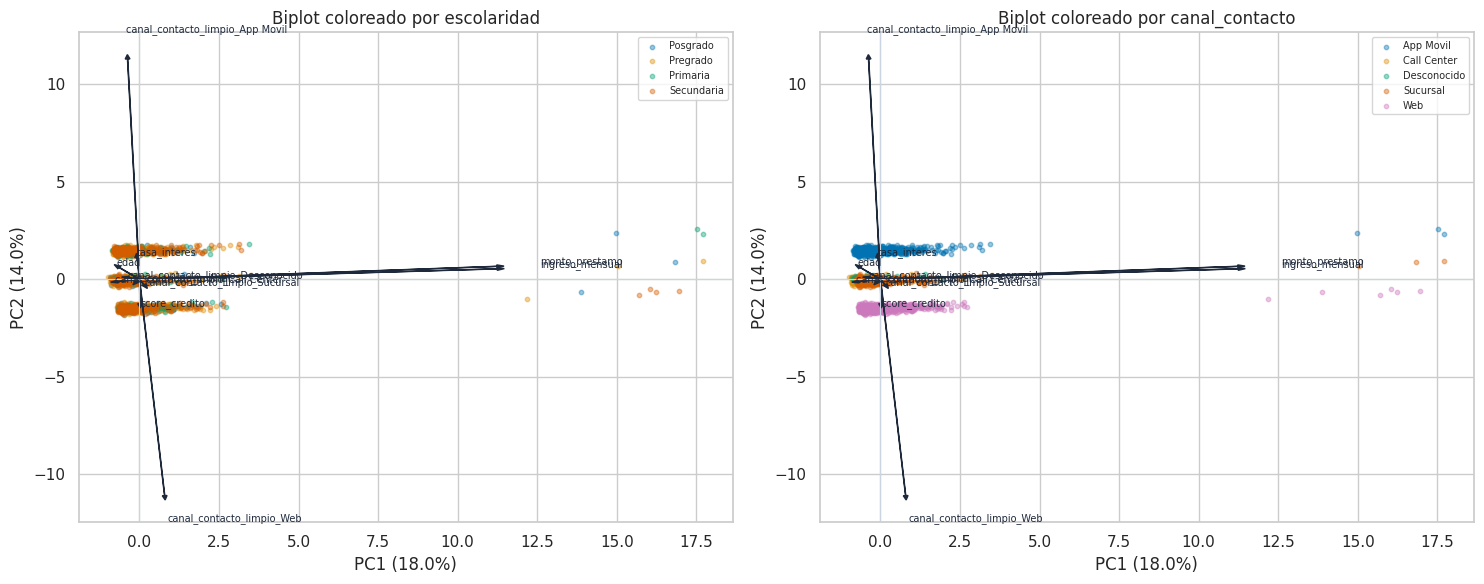

PC1 promedio por nivel de escolaridad:
Posgrado      0.09
Pregrado     -0.06
Primaria      0.01
Secundaria    0.04
dtype: float64

PC2 promedio por canal_contacto:
App Movil      1.48
Call Center   -0.03
Desconocido    0.05
Sucursal      -0.06
Web           -1.48
dtype: float64


In [227]:
def graficar_biplot(pcs, loadings_df, etiquetas_color, titulo, ax, escala_flechas):
    pc1, pc2 = pcs[:, 0], pcs[:, 1]
    categorias = pd.Series(etiquetas_color).astype(str)
    paleta = sns.color_palette("colorblind", n_colors=categorias.nunique())
    for categoria, color in zip(sorted(categorias.unique()), paleta):
        mascara = (categorias == categoria).values
        ax.scatter(pc1[mascara], pc2[mascara], s=10, alpha=0.4, color=color, label=categoria)

    for variable in loadings_df.index:
        vx, vy = loadings_df.loc[variable, "PC1"], loadings_df.loc[variable, "PC2"]
        ax.arrow(0, 0, vx * escala_flechas, vy * escala_flechas, color="#1e293b", width=0.01, head_width=0.15)
        ax.text(vx * escala_flechas * 1.12, vy * escala_flechas * 1.12, variable, fontsize=7, color="#1e293b")

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(titulo)
    ax.legend(fontsize=7, loc="best")
    ax.axhline(0, color="#cbd5e1", linewidth=0.8)
    ax.axvline(0, color="#cbd5e1", linewidth=0.8)


escala = max(np.abs(componentes_principales[:, 0]).max(), np.abs(componentes_principales[:, 1]).max()) * 0.9

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
graficar_biplot(componentes_principales, loadings, df["escolaridad"], "Biplot coloreado por escolaridad", axes[0], escala)
graficar_biplot(componentes_principales, loadings, df["canal_contacto_limpio"], "Biplot coloreado por canal_contacto", axes[1], escala)
plt.tight_layout()
plt.show()

print("PC1 promedio por nivel de escolaridad:")
print(pd.Series(componentes_principales[:, 0]).groupby(df["escolaridad"].values).mean().round(3))
print("\nPC2 promedio por canal_contacto:")
print(pd.Series(componentes_principales[:, 1]).groupby(df["canal_contacto_limpio"].values).mean().round(3))

**Lectura honesta de ambos paneles:**

* **Por `escolaridad` (panel izquierdo): no hay separación visible.** El PC1 promedio apenas varía entre niveles (de 0.01 en Primaria a 0.09 en Posgrado, todos prácticamente sobre 0), y los cuatro colores aparecen completamente entremezclados en la nube de puntos. Esto es consistente con la Sección 6: `escolaridad_ordinal` tiene *loadings* cercanos a 0 en ambas componentes, así que el plano PC1-PC2 simplemente no está capturando la variación (si la hay) asociada al nivel educativo. Sería incorrecto presentar este gráfico como evidencia de un patrón por escolaridad — no lo hay en estas dos componentes.
* **Por `canal_contacto` (panel derecho): la separación es clara y real** a lo largo del eje vertical (PC2): los clientes de `App Movil` se agrupan arriba (PC2 promedio ≈ +1.48) y los de `Web` abajo (PC2 promedio ≈ -1.48), con `Sucursal` y `Call Center` cerca del centro. Esto **no** significa que PCA haya descubierto un patrón financiero interesante sobre el canal de contacto — es, directamente, el reflejo de que PC2 está casi enteramente construida a partir de esas dos columnas dummy (Sección 6). Es una separación real, pero mecánica: el biplot está mostrando, en esencia, la propia codificación One-Hot proyectada sobre dos ejes.

El contraste entre ambos paneles es la lección central de esta sección: **un biplot solo separa grupos si la variable coloreada tiene loadings apreciables en PC1 o PC2** — no hay que sobre-interpretar un patrón visual sin antes revisar la tabla de *loadings* que lo explica.

---
## 8. Limitaciones honestas de PCA ⚠️

1. **Pérdida de interpretabilidad directa.** Cada componente es una combinación lineal de *todas* las columnas originales, no una variable de negocio reconocible. "PC1" no es "ingreso" ni "monto del préstamo" — es una mezcla de ambas (más pequeñas contribuciones del resto), y comunicar resultados basados en componentes a una audiencia no técnica exige siempre traducirlos de vuelta a las variables originales vía la tabla de *loadings*.
2. **Asume relaciones lineales.** PCA solo puede capturar covarianza **lineal** entre columnas. Dos variables con una relación fuerte pero no lineal (por ejemplo, una relación en forma de U) pueden aparecer como poco correlacionadas para PCA y, por lo tanto, terminar en componentes distintas aunque estén profundamente relacionadas.
3. **Extremadamente sensible al escalado — por eso el orden importa.** PCA maximiza varianza, así que una columna con mayor magnitud absoluta domina las primeras componentes si no se estandariza primero — exactamente el problema que motivó el `StandardScaler` de la Sección 2 (y el Cuaderno 02 en general). **Escalar debe ocurrir siempre antes de ajustar PCA, nunca después**: aplicar PCA sobre datos sin escalar y luego intentar "corregir" reescalando los componentes resultantes no es equivalente y no resuelve el problema.
4. **El One-Hot Encoding, combinado con escalado uniforme, puede dominar las primeras componentes.** La Sección 6 lo mostró con evidencia concreta: PC2, PC3 y PC4 terminaron casi enteramente explicadas por columnas dummy individuales de `canal_contacto`, en lugar de por variación financiera. Esto es un efecto conocido y documentado de aplicar PCA sobre variables categóricas codificadas con One-Hot — no es un error del pipeline, pero sí algo que debe anticiparse al interpretar los resultados.
5. **Las columnas dummy introducen dependencia lineal exacta.** Las 5 columnas de `canal_contacto` siempre suman 1 por fila, así que son linealmente dependientes entre sí — la Sección 3 lo confirmó numéricamente: `X_scaled` tiene **rango 10, no 11**, y la última componente principal explica exactamente 0% de la varianza. En datasets con muchas variables categóricas de alta cardinalidad, este efecto se multiplica.
6. **Es una técnica no supervisada.** PCA maximiza varianza total, sin ninguna noción de qué combinación de variables sería más útil para predecir una variable objetivo específica (si existiera una, como `score_credito` o el riesgo de impago). Dos variables con baja varianza pero alto poder predictivo podrían terminar relegadas a componentes tardías que se descartan.

---
## 9. Ejercicio práctico guiado: ¿cuántas componentes hacen falta para el 95% de varianza? 📝

**Contexto:** en la Sección 5 ya se calculó, dentro del bloque de código del *scree plot*, cuántas componentes hacen falta para retener el 80%, 90% y 95% de la varianza. Este ejercicio pide reproducir ese cálculo de forma aislada y explícita, reutilizando el objeto `pca` ya ajustado en la Sección 4.

**Tu misión:**
1. A partir de `pca.explained_variance_ratio_`, calcula el array de varianza acumulada (pista: `np.cumsum`).
2. Encuentra el **primer** número de componentes para el cual esa varianza acumulada alcanza o supera el 95%.
3. Imprime el número de componentes encontrado y la varianza acumulada exacta que se alcanza con ellas.

In [228]:
### TU CÓDIGO AQUÍ ###
# 1. Calcula el array de varianza acumulada a partir de pca.explained_variance_ratio_
varianza_acumulada_ejercicio = None

# 2. Encuentra el primer numero de componentes que alcanza o supera el 95% de varianza acumulada
n_componentes_95 = None

# 3. Imprime el resultado
print(f"Numero de componentes necesarios para retener al menos el 95% de la varianza: {n_componentes_95}")
print(f"Varianza acumulada exacta con ese numero de componentes: {None}")

Numero de componentes necesarios para retener al menos el 95% de la varianza: None
Varianza acumulada exacta con ese numero de componentes: None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Calcula el array de varianza acumulada a partir de pca.explained_variance_ratio_
varianza_acumulada_ejercicio = np.cumsum(pca.explained_variance_ratio_)

# 2. Encuentra el primer numero de componentes que alcanza o supera el 95% de varianza acumulada
n_componentes_95 = int(np.argmax(varianza_acumulada_ejercicio >= 0.95) + 1)

# 3. Imprime el resultado
print(f"Numero de componentes necesarios para retener al menos el 95% de la varianza: {n_componentes_95}")
print(f"Varianza acumulada exacta con ese numero de componentes: {varianza_acumulada_ejercicio[n_componentes_95 - 1]*100:.2f}%")
```

Con este dataset, hacen falta **9 componentes** (de 11 posibles) para alcanzar el 95% de varianza acumulada, y con exactamente esas 9 se llega a **99.74%** — un salto grande respecto al 95%, porque la novena componente por sí sola ya aporta 8.52 puntos porcentuales (Sección 5). El resultado coincide con `n_95` calculado directamente dentro del bloque de código de la Sección 5.

</details>

---
## 10. Resumen Ejecutivo del Módulo 01: Preprocesamiento de los Datos 📌

Este cuaderno cierra el módulo, así que el resumen que sigue no es solo del Cuaderno 04 sino de **todo el recorrido**, de principio a fin, sobre el mismo dataset de solicitudes de crédito:

1. **Cuaderno 00 — Imputación:** antes de imputar hay que diagnosticar *por qué* faltan los datos (MCAR/MAR/MNAR, Rubin 1976). La mediana venció a la media en columnas asimétricas (`ingreso_mensual`); `KNNImputer` e `IterativeImputer` solo aportaron valor donde existía correlación real que explotar, y colapsaron a la media global donde no la había (`score_credito`).
2. **Cuaderno 01 — Outliers:** la regla IQR de Tukey, el puntaje Z y `IsolationForest` detectan tipos distintos de anomalías (univariadas vs. multivariadas), con el fenómeno de enmascaramiento como advertencia central. Las edades imposibles (-3, 150) identificadas ahí se trataron en este mismo cuaderno como parte del pipeline de preprocesamiento.
3. **Cuaderno 02 — Escalado:** `StandardScaler`, `MinMaxScaler`, `RobustScaler` y `PowerTransformer` resuelven problemas distintos (centrar/normalizar, acotar a un rango, resistir outliers, corregir asimetría); la regla de oro contra la fuga de datos —ajustar solo con el conjunto de entrenamiento— aplica a todos ellos por igual.
4. **Cuaderno 03 — Codificación:** `OrdinalEncoder` con orden explícito para `escolaridad`, `OneHotEncoder` para `canal_contacto` (tras limpiar la inconsistencia de mayúsculas/minúsculas), y la trampa de la variable dummy como advertencia para modelos lineales.
5. **Cuaderno 04 — PCA (este cuaderno):** con el pipeline completo de los cuatro cuadernos anteriores ensamblado en unas pocas celdas (Sección 2), PCA comprimió la redundancia real que existía (`ingreso_mensual` + `monto_prestamo` → PC1) pero no pudo comprimir mucho más allá de eso: hicieron falta 7-9 de las 11 columnas para retener 80-95% de la varianza, porque el resto de columnas —incluyendo las dummies de One-Hot— aportan varianza casi independiente entre sí.

**La conclusión que atraviesa las cinco entregas:** no existe una receta universal de preprocesamiento — cada técnica (imputación, tratamiento de outliers, escalado, codificación, reducción de dimensionalidad) tiene supuestos concretos, y aplicarla sin verificarlos sobre los datos reales (como se hizo aquí en cada sección, con números y tablas concretas, nunca solo con teoría) es la diferencia entre un pipeline defendible y uno que simplemente "corre sin errores". Con esto, `dataset_crudo_preprocesamiento.csv` queda transformado, documentado y listo para el siguiente módulo del curso: **Clasificación y Regresión**.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Preprocesamiento de Datos</i>
  </p>
</div>